In [1]:
import numpy as np
from numpy.polynomial import Legendre, Polynomial

n = 5

for i in range(1,n+1):
    p = Legendre.basis(i).convert(kind=Polynomial)
    print(f'P_{i}(x) = {p}')

P_1(x) = 0.0 + 1.0·x
P_2(x) = -0.5 + 0.0·x + 1.5·x²
P_3(x) = 0.0 - 1.5·x + 0.0·x² + 2.5·x³
P_4(x) = 0.375 + 0.0·x - 3.75·x² + 0.0·x³ + 4.375·x⁴
P_5(x) = 0.0 + 1.875·x + 0.0·x² - 8.75·x³ + 0.0·x⁴ + 7.875·x⁵


$P_n(x) = \frac{1}{2^nn!}\frac{d^n}{dx^n}\left(x^2-1\right)^n$

In [4]:
import numpy as np
import math
from sympy import symbols, diff

n = 3
x = symbols('x')
for i in range(1,n+1):
    f = (x**2 - 1)**i
    p = (1/((2**i)*(math.factorial(int(i)))))*diff(f,x,i)
    print(f'P_{i}(x) = {p}')

P_1(x) = 1.0*x
P_2(x) = 1.5*x**2 - 0.5
P_3(x) = 0.5*x*(5*x**2 - 3)


---
$f(z) = \sum_{l=0}^{\infty}\left(c_nP_l(z)\right)$  
$c_n = \frac{2l+1}{2}\int_{-1}^{1}P_l(z)f(z)dz$

---
For $f(z) = sin(\pi z)$  
sin(z) is an odd function, so only the odd lengendre polynomials will be non-zero. I found that at l = 7, the approximation was a good fit of a sin function from -1,1. However, there will always be some error.

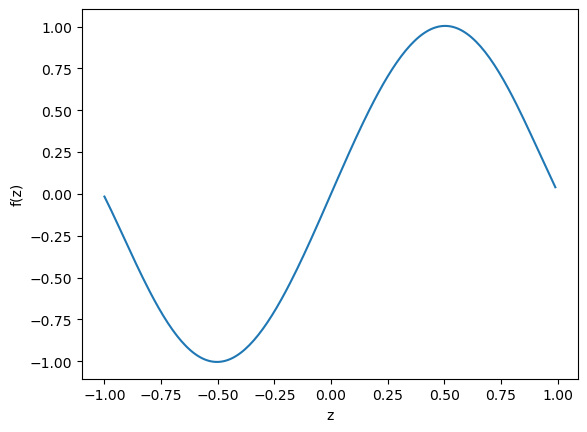

In [37]:
import numpy as np
import scipy.integrate
from numpy.polynomial.legendre import Legendre
import matplotlib.pyplot as plt

l = 6
z = np.arange(-1,1,0.01)
f = np.zeros(z.size)
for i in range(l+1):
    cn = ((2*i+1)/2)*(scipy.integrate.trapezoid(Legendre.basis(i)(z)*np.sin(np.pi*z),x=z))
    f += cn*Legendre.basis(i)(z)
    
plt.plot(z,f)
plt.xlabel('z')
plt.ylabel('f(z)');

When I provide a range outside of -1 to 1, the function quickly diverges and becomes an unhelpful approximation of f(z). As more terms are added, the function gets wore a the ends blow up more, sooner. 

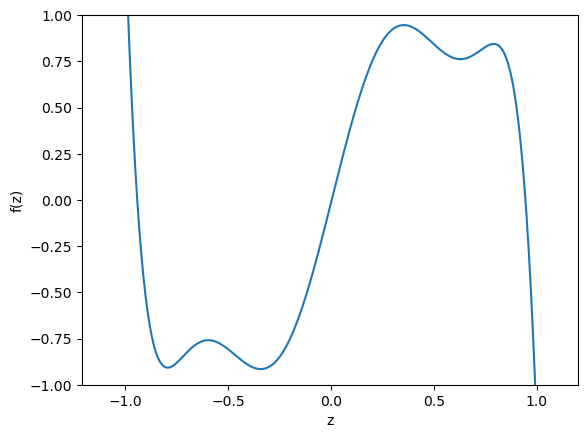

In [61]:
import numpy as np
import scipy.integrate
from numpy.polynomial.legendre import Legendre
import matplotlib.pyplot as plt

l = 7
z = np.arange(-1.1,1.1,0.01)
f = np.zeros(z.size)
for i in range(l+1):
    cn = ((2*i+1)/2)*(scipy.integrate.trapezoid(Legendre.basis(i)(z)*np.sin(np.pi*z),x=z))
    f += cn*Legendre.basis(i)(z)
    
plt.plot(z,f)
plt.xlabel('z')
plt.ylabel('f(z)')
plt.axis(ymin=-1,ymax=1);

---
For $g(z) = sin(3\pi z)$  
I found that since the function was compressed horizontally by a factor of three, the summation needed much more precision, around l = 13.

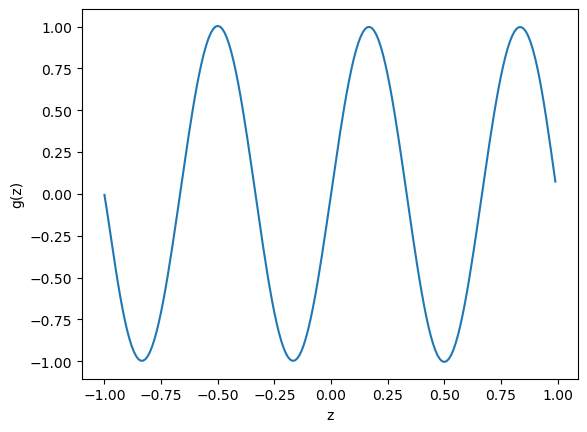

In [55]:
l = 13
z = np.arange(-1,1,0.01)
g = np.zeros(z.size)
for i in range(l+1):
    cn = ((2*i+1)/2)*(scipy.integrate.trapezoid(Legendre.basis(i)(z)*np.sin(3*np.pi*z),x=z))
    g += cn*Legendre.basis(i)(z)
    
plt.plot(z,g)
plt.xlabel('z')
plt.ylabel('g(z)');

Similarly to before, when I provide a range outside of -1 to 1, the function quickly diverges and becomes an unhelpful approximation of g(z). As more terms are added, the function gets wore a the ends blow up more, sooner.

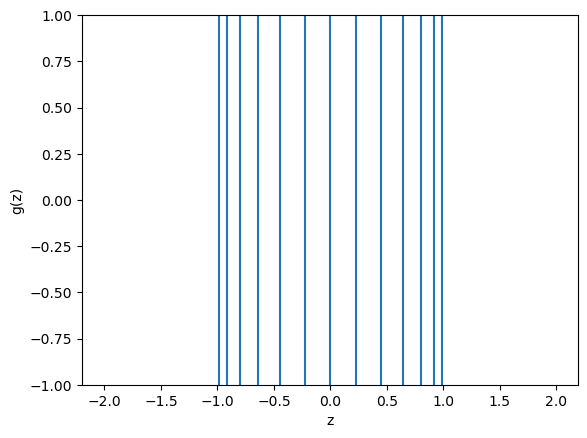

In [63]:
l = 13
z = np.arange(-2,2,0.01)
g = np.zeros(z.size)
for i in range(l+1):
    cn = ((2*i+1)/2)*(scipy.integrate.trapezoid(Legendre.basis(i)(z)*np.sin(3*np.pi*z),x=z))
    g += cn*Legendre.basis(i)(z)
    
plt.plot(z,g)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.axis(ymin=-1,ymax=1);